<a href="https://colab.research.google.com/github/alanagadelha/DeepLearning_AntarticaWork/blob/main/SSCAD2025_Plotagem_dos_Dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MERGE nos dados .CSV do ICON

In [ ]:
!rm -rf /content/sample_data

In [ ]:
!rm -rf *.csv

In [ ]:
lista_arquivos = ['/content/ICONANT_dados_SCRM_202504.csv',
 '/content/ICONANT_dados_SCRM_202406.csv',
 '/content/ICONANT_dados_SCRM_202310.csv',
 '/content/ICONANT_dados_SCRM_202408.csv',
 '/content/ICONANT_dados_SCRM_202401.csv',
 '/content/ICONANT_dados_SCRM_202411.csv',
 '/content/ICONANT_dados_SCRM_202410.csv',
 '/content/ICONANT_dados_SCRM_202404.csv',
 '/content/ICONANT_dados_SCRM_202412.csv',
 '/content/ICONANT_dados_SCRM_202409.csv',
 '/content/ICONANT_dados_SCRM_202311.csv',
 '/content/ICONANT_dados_SCRM_202402.csv',
 '/content/ICONANT_dados_SCRM_202405.csv',
 '/content/ICONANT_dados_SCRM_202503.csv',
 '/content/ICONANT_dados_SCRM_202505.csv',
 '/content/ICONANT_dados_SCRM_202502.csv',
 '/content/ICONANT_dados_SCRM_202407.csv',
 '/content/ICONANT_dados_SCRM_202312.csv',
 '/content/ICONANT_dados_SCRM_202501.csv',
 '/content/ICONANT_dados_SCRM_202309.csv',
 '/content/ICONANT_dados_SCRM_202403.csv']

for arquivo in lista_arquivos:
  baixar = arquivo.split('/content/')[1]
  !wget https://ygor.ml/uff/sscad2025/dados_ICON/$baixar

--2025-08-04 20:23:15--  https://ygor.ml/uff/sscad2025/dados_ICON/ICONANT_dados_SCRM_202504.csv
Resolving ygor.ml (ygor.ml)... 177.73.233.43
Connecting to ygor.ml (ygor.ml)|177.73.233.43|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1810556 (1.7M) [text/csv]
Saving to: ‘ICONANT_dados_SCRM_202504.csv’

ICONANT_dados_SCRM_ 100%[===================>]   1.73M  1.69MB/s    in 1.0s    

2025-08-04 20:23:17 (1.69 MB/s) - ‘ICONANT_dados_SCRM_202504.csv’ saved [1810556/1810556]

--2025-08-04 20:23:17--  https://ygor.ml/uff/sscad2025/dados_ICON/ICONANT_dados_SCRM_202406.csv
Resolving ygor.ml (ygor.ml)... 177.73.233.43
Connecting to ygor.ml (ygor.ml)|177.73.233.43|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1812780 (1.7M) [text/csv]
Saving to: ‘ICONANT_dados_SCRM_202406.csv’

ICONANT_dados_SCRM_ 100%[===================>]   1.73M  2.07MB/s    in 0.8s    

2025-08-04 20:23:18 (2.07 MB/s) - ‘ICONANT_dados_SCRM_202406.csv’ saved [1812780/1812

In [ ]:
import pandas as pd
import glob

# Get a list of all CSV files in the /content directory
all_files = glob.glob('/content/*.csv')

In [ ]:
all_files

['/content/ICONANT_dados_SCRM_202504.csv',
 '/content/ICONANT_dados_SCRM_202406.csv',
 '/content/ICONANT_dados_SCRM_202310.csv',
 '/content/ICONANT_dados_SCRM_202408.csv',
 '/content/ICONANT_dados_SCRM_202401.csv',
 '/content/ICONANT_dados_SCRM_202411.csv',
 '/content/ICONANT_dados_SCRM_202410.csv',
 '/content/ICONANT_dados_SCRM_202404.csv',
 '/content/ICONANT_dados_SCRM_202412.csv',
 '/content/ICONANT_dados_SCRM_202409.csv',
 '/content/ICONANT_dados_SCRM_202311.csv',
 '/content/ICONANT_dados_SCRM_202402.csv',
 '/content/ICONANT_dados_SCRM_202405.csv',
 '/content/ICONANT_dados_SCRM_202503.csv',
 '/content/ICONANT_dados_SCRM_202505.csv',
 '/content/ICONANT_dados_SCRM_202502.csv',
 '/content/ICONANT_dados_SCRM_202407.csv',
 '/content/ICONANT_dados_SCRM_202312.csv',
 '/content/ICONANT_dados_SCRM_202501.csv',
 '/content/ICONANT_dados_SCRM_202309.csv',
 '/content/ICONANT_dados_SCRM_202403.csv']

In [ ]:
# Create a list to hold the dataframes
all_df = []

# Loop through the files, read each into a dataframe, and append it to the list
for f in all_files:
    df = pd.read_csv(f)
    all_df.append(df)

# Concatenate all the dataframes in the list into a single dataframe
merged_df = pd.concat(all_df, ignore_index=True)

# Save the merged dataframe to a new CSV file
merged_df.to_csv('merged.csv', index=False)

print("Todos os arquivos CSV foram juntados em 'merged.csv'")

Todos os arquivos CSV foram juntados em 'merged.csv'


In [ ]:
!grep -vE '^(#|cdo)' merged.csv > icon_merged_filtrado_semcdo.csv

In [ ]:
import pandas as pd

csv_path = '/content/icon_merged_filtrado_semcdo.csv'
output_path_etl_icon = '/content/icon_merged_filtrado_semcdo_output.csv'

# Leitura com proteção contra linhas ruins
df = pd.read_csv(
    csv_path,
    sep='\s+',
    names=["date", "time", "var", "value"],
    comment='#',
    engine='python',
    on_bad_lines='skip'
)

# Filtra apenas linhas com data no formato correto
df = df[df["date"].str.match(r"\d{4}-\d{2}-\d{2}")]

# Junta data e hora
df["datetime"] = pd.to_datetime(df["date"] + " " + df["time"], errors='coerce')
df = df.dropna(subset=["datetime"])  # Remove erros de datetime

# Mantém colunas úteis
df = df[["datetime", "var", "value"]]

# Diagnóstico de duplicatas
dupes = df.duplicated(subset=["datetime", "var"], keep=False)
if dupes.any():
    print("⚠️ Há duplicatas no par (datetime, var):")
    print(df[dupes].sort_values(by=["datetime", "var"]).head())

# Pivotagem com média em caso de duplicata
df_wide = df.pivot_table(index="datetime", columns="var", values="value", aggfunc='mean')

# Salvar resultado
df_wide.to_csv(output_path_etl_icon)

# Exibir os primeiros valores
print(df.head())

⚠️ Há duplicatas no par (datetime, var):
         datetime  var       value
748489 2023-09-02  10u  -16.143860
749347 2023-09-02  10u  -13.931210
748490 2023-09-02  10v    3.860437
749348 2023-09-02  10v    3.526037
748497 2023-09-02   2d  261.576400
    datetime   var      value
0 2025-04-01  CLCL   67.48633
1 2025-04-01  CLCM   34.60938
2 2025-04-01  CLCH    0.00000
3 2025-04-01  CLCT   81.09570
4 2025-04-01  ceil  347.00000


In [ ]:
from datetime import datetime

registros = []

with open(csv_path, 'r', encoding='utf-8') as f:
    for linha in f:
        if linha.startswith('#'):
            continue
        partes = linha.strip().split()
        if len(partes) != 4:
            continue  # ignora linhas mal formatadas
        data, hora, var, valor = partes
        try:
            dt = datetime.strptime(f"{data} {hora}", "%Y-%m-%d %H:%M:%S")
            registros.append((dt, var, float(valor)))
        except Exception as e:
            print(f"Erro ao converter linha: {linha.strip()} -> {e}")

# Converte para DataFrame
df = pd.DataFrame(registros, columns=["datetime", "var", "value"])

# Pivot seguro
df_wide = df.pivot_table(index="datetime", columns="var", values="value", aggfunc='mean')
df_wide.to_csv(output_path_etl_icon)

print(df.head())

    datetime   var      value
0 2025-04-01  CLCL   67.48633
1 2025-04-01  CLCM   34.60938
2 2025-04-01  CLCH    0.00000
3 2025-04-01  CLCT   81.09570
4 2025-04-01  ceil  347.00000


In [ ]:
display(df_wide)

var,10u,10v,2d,2r,2t,CAPE_CON,CIN_ML,CLCH,CLCL,CLCM,...,max_2t,max_i10fg,min_2t,prmsl,sde,sp,tp,utaua,vis,vtaua
datetime,,,,,,,,,,,,,,,,,,,,,
2023-09-01 00:00:00,5.548670,-9.573135,270.5673,88.32837,272.2492,4.171875,0.506226,100.000000,98.48242,100.00000,...,272.2500,14.57227,272.2453,97353.76,0.060547,97312.64,0.000000,0.000000,11526.0,0.000000
2023-09-01 03:00:00,0.118757,-7.611288,271.6519,93.40012,272.5814,14.589840,0.006226,99.455080,83.42578,51.86914,...,272.6562,15.14160,272.3141,97421.90,0.060547,97384.02,0.164062,0.002923,5650.0,-0.137821
2023-09-01 06:00:00,-1.182783,-5.712227,271.5755,92.94511,272.5716,6.482422,0.006226,3.642578,89.62500,41.87695,...,272.6875,10.30176,272.2828,97449.81,0.060547,97409.27,0.239258,-0.017993,5986.0,-0.090039
2023-09-01 09:00:00,-6.849104,3.863632,268.7796,93.48045,269.6761,24.392580,0.006226,37.130860,99.91406,100.00000,...,272.5938,10.54590,269.5181,97571.41,0.076172,97537.47,2.317383,-0.110038,310.5,0.063833
2023-09-01 12:00:00,-11.003030,2.527594,266.7294,85.87453,268.7293,6.896484,0.006226,0.349609,88.82031,36.82422,...,272.5938,15.16602,268.5078,97740.73,0.097656,97702.43,5.386719,-0.263396,4061.0,0.063954
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-03 12:00:00,-5.939865,-0.065056,270.8412,85.00786,273.0499,2.277344,-999.900000,68.861330,52.21875,100.00000,...,273.3125,7.97168,272.8591,98934.89,1.070312,98893.31,5.789062,-0.082285,21286.0,-0.001393
2025-06-03 15:00:00,-8.991280,0.800179,271.0650,88.38481,272.7463,10.890620,-999.900000,65.699220,80.05469,100.00000,...,273.2188,11.76367,272.6242,98872.81,1.070312,98829.43,6.039062,-0.145315,9890.0,0.011831
2025-06-03 18:00:00,-10.901380,1.343147,270.6567,89.11528,272.2191,5.910156,0.006226,74.640620,89.05078,100.00000,...,273.2188,14.80957,272.1555,98826.66,1.074219,98785.43,7.656250,-0.238942,4322.0,0.028069


In [ ]:
filtro_pos_merge = df_wide.loc[df_wide.index == '2024-06-04 00:00:00']
display(filtro_pos_merge)

var,10u,10v,2d,2r,2t,CAPE_CON,CIN_ML,CLCH,CLCL,CLCM,...,max_2t,max_i10fg,min_2t,prmsl,sde,sp,tp,utaua,vis,vtaua
datetime,,,,,,,,,,,,,,,,,,,,,
2024-06-04,1.26145,2.753464,268.376217,85.75615,270.4353,3.955404,-166.33752,0.0,52.820313,21.166342,...,271.390617,7.770996,270.211233,98741.131667,0.246094,98693.77,2.176758,0.023237,12943.416667,0.02551


In [ ]:
!wget https://ygor.ml/uff/sscad2025/comparacao_modelos_previsao.csv

--2025-08-04 20:24:10--  https://ygor.ml/uff/sscad2025/comparacao_modelos_previsao.csv
Resolving ygor.ml (ygor.ml)... 177.73.233.43
Connecting to ygor.ml (ygor.ml)|177.73.233.43|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4106 (4.0K) [text/csv]
Saving to: ‘comparacao_modelos_previsao.csv’

comparacao_modelos_ 100%[===================>]   4.01K  --.-KB/s    in 0s      

2025-08-04 20:24:10 (58.0 MB/s) - ‘comparacao_modelos_previsao.csv’ saved [4106/4106]



In [ ]:
df_comparacao = pd.read_csv('/content/comparacao_modelos_previsao.csv')
df_comparacao

,Timestamp,Observado,Previsao_Baseline,Previsao_Linear,Previsao_MLP,Previsao_MLP3inp,Previsao_CNN,Previsao_LSTM,Previsao_BiLSTM
0,2024-04-09 05:00:00,5.5,4.9,4.761049,3.381356,3.381356,4.623024,5.665557,5.375241
1,2024-04-09 06:00:00,7.0,5.5,5.157893,3.553315,3.553315,5.754916,6.513269,6.953417
2,2024-04-09 07:00:00,5.7,7.0,6.394438,4.419686,4.419686,5.273275,5.649269,5.735304
3,2024-04-09 08:00:00,5.0,5.7,5.185299,3.504148,3.504148,4.819186,5.278936,5.033417
4,2024-04-09 09:00:00,6.0,5.0,4.596821,3.104706,3.104706,4.938722,5.657647,5.973281
5,2024-04-09 10:00:00,5.9,6.0,5.378449,3.690757,3.690757,4.993639,6.142653,5.851919
6,2024-04-09 11:00:00,6.0,5.9,5.448820,3.660976,3.660976,5.114970,6.472387,6.112422
7,2024-04-09 12:00:00,7.0,6.0,5.487715,3.693333,3.693333,5.804405,6.570675,6.937909
8,2024-04-09 13:00:00,5.8,7.0,6.463813,4.382296,4.382296,5.334906,6.434859,5.713898
9,2024-04-09 14:00:00,6.0,5.8,5.430897,3.673802,3.673802,5.352045,6.115956,5.771499


In [ ]:
df_icon = pd.read_csv(output_path_etl_icon)
df_icon.head()

,datetime,10u,10v,2d,2r,2t,CAPE_CON,CIN_ML,CLCH,CLCL,...,max_2t,max_i10fg,min_2t,prmsl,sde,sp,tp,utaua,vis,vtaua
0,2023-09-01 00:00:00,5.548670,-9.573135,270.5673,88.32837,272.2492,4.171875,0.506226,100.000000,98.48242,...,272.2500,14.57227,272.2453,97353.76,0.060547,97312.64,0.000000,0.000000,11526.0,0.000000
1,2023-09-01 03:00:00,0.118757,-7.611288,271.6519,93.40012,272.5814,14.589840,0.006226,99.455080,83.42578,...,272.6562,15.14160,272.3141,97421.90,0.060547,97384.02,0.164062,0.002923,5650.0,-0.137821
2,2023-09-01 06:00:00,-1.182783,-5.712227,271.5755,92.94511,272.5716,6.482422,0.006226,3.642578,89.62500,...,272.6875,10.30176,272.2828,97449.81,0.060547,97409.27,0.239258,-0.017993,5986.0,-0.090039
3,2023-09-01 09:00:00,-6.849104,3.863632,268.7796,93.48045,269.6761,24.392580,0.006226,37.130860,99.91406,...,272.5938,10.54590,269.5181,97571.41,0.076172,97537.47,2.317383,-0.110038,310.5,0.063833
4,2023-09-01 12:00:00,-11.003030,2.527594,266.7294,85.87453,268.7293,6.896484,0.006226,0.349609,88.82031,...,272.5938,15.16602,268.5078,97740.73,0.097656,97702.43,5.386719,-0.263396,4061.0,0.063954


In [ ]:
df_comparacao['Timestamp'] = pd.to_datetime(df_comparacao['Timestamp'])
df_icon['datetime'] = pd.to_datetime(df_icon['datetime'])

df_icon_filtrado = df_icon[df_icon['datetime'].isin(df_comparacao['Timestamp'])]
df_icon_filtrado.reset_index(drop=True, inplace=True)

display(df_icon_filtrado)

,datetime,10u,10v,2d,2r,2t,CAPE_CON,CIN_ML,CLCH,CLCL,...,max_2t,max_i10fg,min_2t,prmsl,sde,sp,tp,utaua,vis,vtaua
0,2024-04-09 06:00:00,-3.732122,1.859964,266.05878,80.617214,268.917500,3.090234,-196.306269,0.000000,42.925781,...,271.206260,8.174609,268.528620,98912.194000,0.668359,98865.706,8.874999,-0.063678,17258.000000,0.025034
1,2024-04-09 09:00:00,-8.138051,1.619938,264.81706,81.584470,267.460540,4.550390,0.006226,0.000000,54.650782,...,269.093760,11.545314,267.014740,99117.116000,0.668359,99070.336,8.967580,-0.168822,16872.000000,0.032914
2,2024-04-09 12:00:00,-7.725004,1.583825,263.54792,79.407162,266.512600,5.108594,0.006226,0.000000,70.908984,...,269.093760,11.623634,266.032480,99377.990000,0.668359,99330.748,9.028320,-0.159642,17826.500000,0.032558
3,2024-04-09 15:00:00,-6.057814,1.307450,262.92548,76.923198,266.284840,3.721094,0.006226,0.000000,81.180858,...,266.793760,10.894921,265.693920,99632.842000,0.668555,99583.320,9.104881,-0.124998,18397.600000,0.029731
4,2024-04-09 18:00:00,-1.915933,1.108881,263.17506,74.194912,267.013580,2.460156,0.006226,0.000000,70.270312,...,267.318760,8.495312,265.695460,99828.248000,0.668945,99777.046,9.171094,-0.046415,19608.100000,0.024513
5,2024-04-09 21:00:00,2.837724,1.920205,263.50036,66.351774,268.842100,3.556641,0.006226,0.000000,51.992188,...,269.056240,7.723632,266.622760,99927.088000,0.668945,99876.862,9.243165,0.033306,25874.300000,0.024623
6,2024-04-10 00:00:00,6.591118,3.020560,265.94125,69.614975,270.745867,9.276042,-333.295850,18.487630,51.456380,...,270.953117,10.467774,267.487833,99894.231667,0.557454,99847.925,7.703776,0.083748,24436.666667,0.038565
7,2024-04-10 03:00:00,10.402160,3.042767,268.38712,75.623422,272.135260,3.209375,-397.281264,71.528905,83.506642,...,272.337500,15.151562,271.023820,99674.584000,0.655664,99628.124,4.412647,0.264101,21287.700000,0.076023


In [ ]:
df_icon_filtrado = df_icon_filtrado[['datetime', '2t']]
display(df_icon_filtrado)

,datetime,2t
0,2024-04-09 06:00:00,268.917500
1,2024-04-09 09:00:00,267.460540
2,2024-04-09 12:00:00,266.512600
3,2024-04-09 15:00:00,266.284840
4,2024-04-09 18:00:00,267.013580
5,2024-04-09 21:00:00,268.842100
6,2024-04-10 00:00:00,270.745867
7,2024-04-10 03:00:00,272.135260


In [ ]:
df_icon_filtrado['2t'] = df_icon_filtrado['2t'] - 273.15
display(df_icon_filtrado)

,datetime,2t
0,2024-04-09 06:00:00,-4.232500
1,2024-04-09 09:00:00,-5.689460
2,2024-04-09 12:00:00,-6.637400
3,2024-04-09 15:00:00,-6.865160
4,2024-04-09 18:00:00,-6.136420
5,2024-04-09 21:00:00,-4.307900
6,2024-04-10 00:00:00,-2.404133
7,2024-04-10 03:00:00,-1.014740


In [ ]:
df_comparacao = pd.merge(df_comparacao, df_icon_filtrado, left_on='Timestamp', right_on='datetime', how='left')
df_comparacao.rename(columns={'2t': 'Previsao_ICON'}, inplace=True)
df_comparacao.drop(columns=['datetime'], inplace=True)
display(df_comparacao)

,Timestamp,Observado,Previsao_Baseline,Previsao_Linear,Previsao_MLP,Previsao_MLP3inp,Previsao_CNN,Previsao_LSTM,Previsao_BiLSTM,Previsao_ICON
0,2024-04-09 05:00:00,5.5,4.9,4.761049,3.381356,3.381356,4.623024,5.665557,5.375241,NaN
1,2024-04-09 06:00:00,7.0,5.5,5.157893,3.553315,3.553315,5.754916,6.513269,6.953417,-4.232500
2,2024-04-09 07:00:00,5.7,7.0,6.394438,4.419686,4.419686,5.273275,5.649269,5.735304,NaN
3,2024-04-09 08:00:00,5.0,5.7,5.185299,3.504148,3.504148,4.819186,5.278936,5.033417,NaN
4,2024-04-09 09:00:00,6.0,5.0,4.596821,3.104706,3.104706,4.938722,5.657647,5.973281,-5.689460
5,2024-04-09 10:00:00,5.9,6.0,5.378449,3.690757,3.690757,4.993639,6.142653,5.851919,NaN
6,2024-04-09 11:00:00,6.0,5.9,5.448820,3.660976,3.660976,5.114970,6.472387,6.112422,NaN
7,2024-04-09 12:00:00,7.0,6.0,5.487715,3.693333,3.693333,5.804405,6.570675,6.937909,-6.637400
8,2024-04-09 13:00:00,5.8,7.0,6.463813,4.382296,4.382296,5.334906,6.434859,5.713898,NaN
9,2024-04-09 14:00:00,6.0,5.8,5.430897,3.673802,3.673802,5.352045,6.115956,5.771499,NaN


In [ ]:
df_comparacao.drop(columns=['Previsao_ICON'], inplace=True)

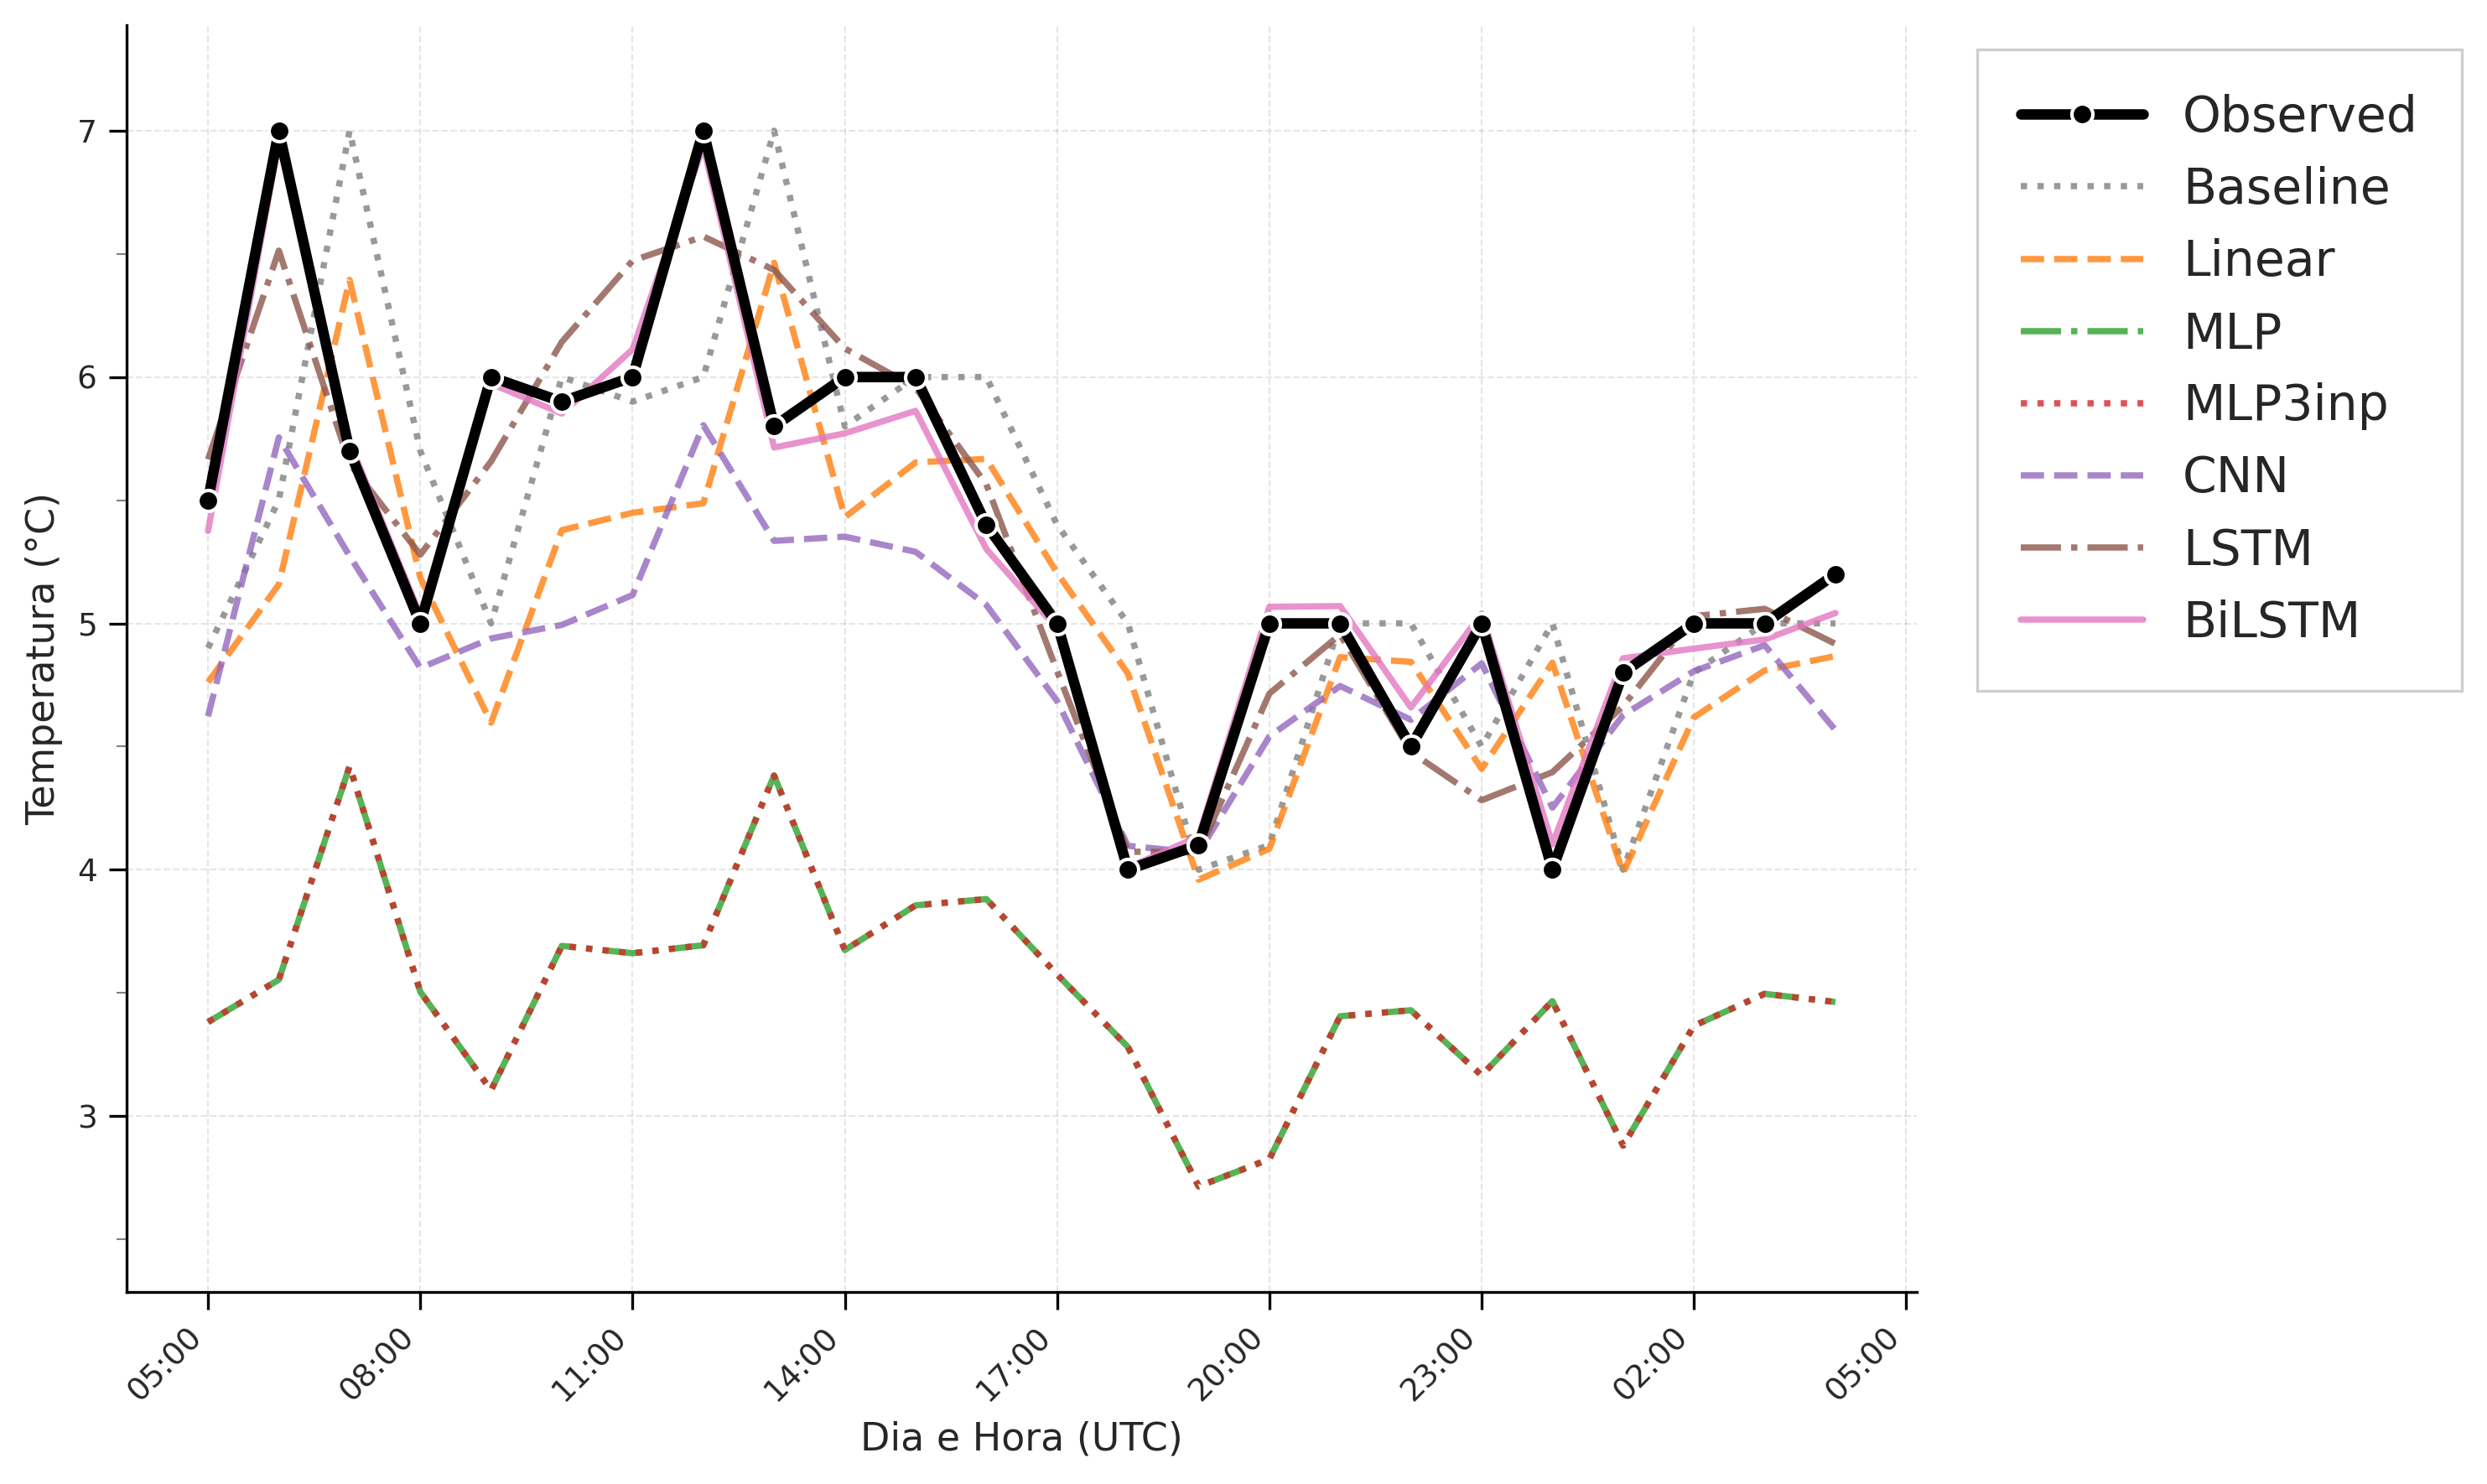

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.dates import DateFormatter, HourLocator, DayLocator
import pandas as pd

# Configuração para publicação científica
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica', 'sans-serif']
plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['lines.linewidth'] = 1.5

# Criar figura com proporções adequadas para publicação
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# Paleta de cores científica (colorblind-friendly) adaptada para seus modelos
colors = {
    'Observado': '#000000',      # Preto
    'Baseline': '#808080',       # Cinza
    'Linear': '#FF7F0E',         # Laranja
    'MLP': '#2CA02C',           # Verde
    'MLP3inp': '#D62728',       # Vermelho
    'CNN': '#9467BD',           # Roxo
    'LSTM': '#8C564B',          # Marrom
    'BiLSTM': '#E377C2',        # Rosa
    'ICON': '#17BECF'           # Ciano
}

# Estilo de linha para cada modelo
line_styles = {
    'Observado': '-',
    'Baseline': ':',
    'Linear': '--',
    'MLP': '-.',
    'MLP3inp': ':',
    'CNN': '--',
    'LSTM': '-.',
    'BiLSTM': '-',
    'ICON': '--'
}

# Converter Timestamp para datetime se necessário
if not pd.api.types.is_datetime64_any_dtype(df_comparacao['Timestamp']):
    df_comparacao['Timestamp'] = pd.to_datetime(df_comparacao['Timestamp'])

# Plotar dados observados com destaque
ax.plot(df_comparacao['Timestamp'], df_comparacao['Observado'],
        label='Observed', linewidth=3, color=colors['Observado'],
        linestyle=line_styles['Observado'], marker='o', markersize=6,
        markevery=max(1, len(df_comparacao)//20),
        markeredgecolor='white', markeredgewidth=1,
        zorder=10)

# Plotar previsões dos modelos
model_columns = [col for col in df_comparacao.columns if col.startswith('Previsao_')]

for model_col in model_columns:
    model_name = model_col.replace('Previsao_', '')

    # Pular valores NaN
    mask = ~df_comparacao[model_col].isna()
    if mask.sum() > 0:  # Só plotar se houver dados válidos
        ax.plot(df_comparacao.loc[mask, 'Timestamp'],
                df_comparacao.loc[mask, model_col],
                label=model_name,
                linewidth=1.8,
                color=colors.get(model_name, '#888888'),
                linestyle=line_styles.get(model_name, '-'),
                alpha=0.8)

# Configurar eixos
ax.set_xlabel('Dia e Hora (UTC)', fontsize=11, fontweight='normal')
ax.set_ylabel('Temperatura (°C)', fontsize=11, fontweight='normal')

# Título para publicação
# ax.set_title('Temperature Forecasting: Comparison of Machine Learning Models',
#              fontsize=12, fontweight='bold', pad=15)

# Formatar eixo x para datas
time_range = df_comparacao['Timestamp'].max() - df_comparacao['Timestamp'].min()

if time_range.days >= 7:
    # Para períodos longos, mostrar dia e mês
    ax.xaxis.set_major_formatter(DateFormatter('%m/%d'))
    ax.xaxis.set_major_locator(DayLocator(interval=max(1, time_range.days//7)))
elif time_range.days >= 1:
    # Para alguns dias, mostrar dia e hora
    ax.xaxis.set_major_formatter(DateFormatter('%d/%m %Hh'))
    ax.xaxis.set_major_locator(HourLocator(interval=max(1, 24//4)))
else:
    # Para períodos curtos, mostrar apenas hora
    ax.xaxis.set_major_formatter(DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(HourLocator(interval=max(1, len(df_comparacao)//8)))

# Rotacionar labels do eixo x
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Grade sutil
ax.grid(True, linestyle='--', alpha=0.2, linewidth=0.5, color='gray')
ax.set_axisbelow(True)

# Configurar spines
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('black')
    ax.spines[spine].set_linewidth(0.8)

# Ajustar limites do eixo y com margem
# Coletar apenas valores válidos (não-NaN)
y_data = []
for col in df_comparacao.columns:
    if col != 'Timestamp':
        valid_data = df_comparacao[col].dropna()
        if len(valid_data) > 0:
            y_data.extend(valid_data.values)

if y_data:
    y_min, y_max = min(y_data), max(y_data)
    y_margin = (y_max - y_min) * 0.1
    ax.set_ylim(y_min - y_margin, y_max + y_margin)

# Adicionar ticks menores
ax.tick_params(axis='both', which='major', width=0.8, length=5, color='black')
ax.tick_params(axis='both', which='minor', width=0.5, length=3, color='gray')
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.5))  # Ticks menores a cada 0.5°C

# Legenda otimizada
# Ordenar legenda por performance (opcional - remover se não desejar)
handles, labels = ax.get_legend_handles_labels()
# Manter "Observed" primeiro
if 'Observed' in labels:
    obs_idx = labels.index('Observed')
    handles = [handles[obs_idx]] + handles[:obs_idx] + handles[obs_idx+1:]
    labels = [labels[obs_idx]] + labels[:obs_idx] + labels[obs_idx+1:]

legend = ax.legend(handles, labels,
                   loc='upper left', bbox_to_anchor=(1.02, 1),
                   frameon=True, fancybox=False,
                   shadow=False, ncol=1,
                   handlelength=2.5, handletextpad=0.8,
                   borderpad=0.9, framealpha=0.95,
                   fontsize=14,
                   edgecolor='#CCCCCC', facecolor='white')
legend.get_frame().set_linewidth(0.8)

# Adicionar uma área sombreada para destacar período específico (opcional)
# Por exemplo, destacar as primeiras 24 horas
# ax.axvspan(df_comparacao['Timestamp'].iloc[0],
#            df_comparacao['Timestamp'].iloc[0] + pd.Timedelta(hours=24),
#            alpha=0.1, color='gray', label='Training period')

# Layout otimizado
plt.tight_layout()

# Salvar em alta qualidade
plt.savefig('temperature_forecast_comparison.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('temperature_forecast_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

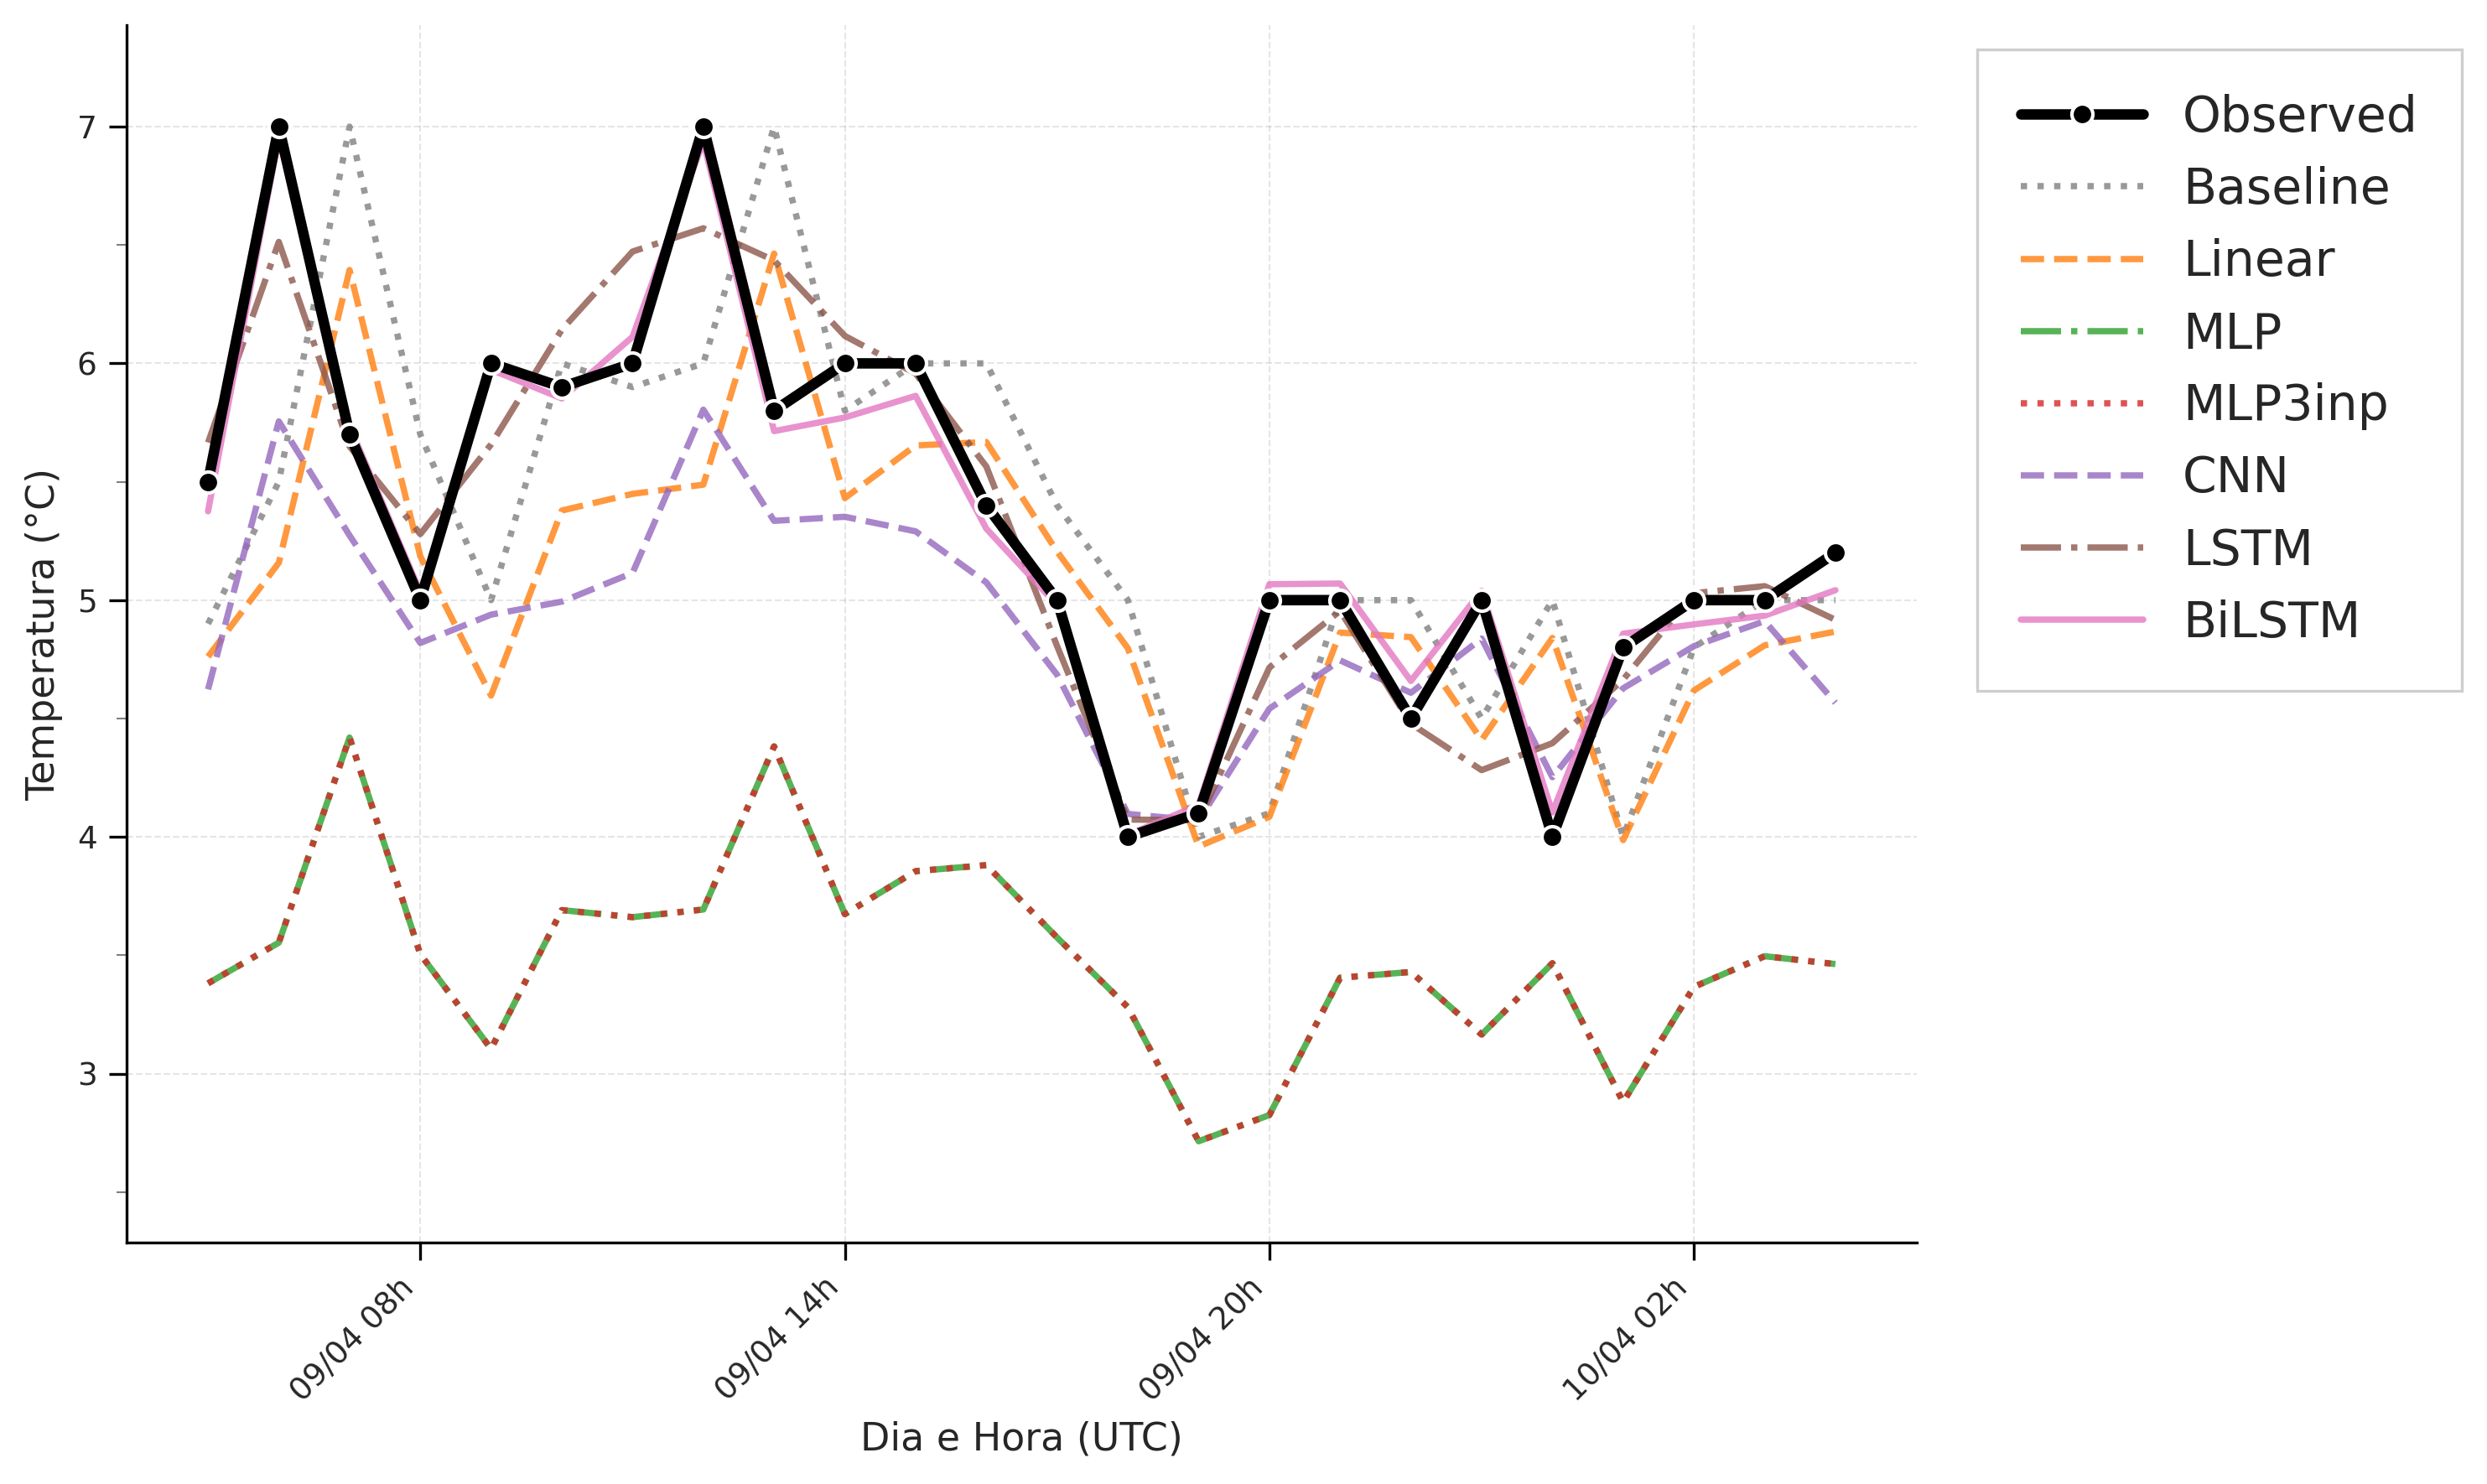

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.dates import DateFormatter, HourLocator, DayLocator
import pandas as pd
from matplotlib.dates import DateFormatter

# Formatar eixo y como datas
ax.yaxis.set_major_formatter(DateFormatter('%d/%m'))  # ou '%d/%b' para "03/ago"

# Configuração para publicação científica
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica', 'sans-serif']
plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['lines.linewidth'] = 1.5

# Criar figura com proporções adequadas para publicação
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# Paleta de cores científica (colorblind-friendly) adaptada para seus modelos
colors = {
    'Observado': '#000000',      # Preto
    'Baseline': '#808080',       # Cinza
    'Linear': '#FF7F0E',         # Laranja
    'MLP': '#2CA02C',           # Verde
    'MLP3inp': '#D62728',       # Vermelho
    'CNN': '#9467BD',           # Roxo
    'LSTM': '#8C564B',          # Marrom
    'BiLSTM': '#E377C2',        # Rosa
    'ICON': '#17BECF'           # Ciano
}

# Estilo de linha para cada modelo
line_styles = {
    'Observado': '-',
    'Baseline': ':',
    'Linear': '--',
    'MLP': '-.',
    'MLP3inp': ':',
    'CNN': '--',
    'LSTM': '-.',
    'BiLSTM': '-',
    'ICON': '--'
}

# Converter Timestamp para datetime se necessário
if not pd.api.types.is_datetime64_any_dtype(df_comparacao['Timestamp']):
    df_comparacao['Timestamp'] = pd.to_datetime(df_comparacao['Timestamp'])

# Plotar dados observados com destaque
ax.plot(df_comparacao['Timestamp'], df_comparacao['Observado'],
        label='Observed', linewidth=3, color=colors['Observado'],
        linestyle=line_styles['Observado'], marker='o', markersize=6,
        markevery=max(1, len(df_comparacao)//20),
        markeredgecolor='white', markeredgewidth=1,
        zorder=10)

# Plotar previsões dos modelos
model_columns = [col for col in df_comparacao.columns if col.startswith('Previsao_')]

for model_col in model_columns:
    model_name = model_col.replace('Previsao_', '')

    # Pular valores NaN
    mask = ~df_comparacao[model_col].isna()
    if mask.sum() > 0:  # Só plotar se houver dados válidos
        ax.plot(df_comparacao.loc[mask, 'Timestamp'],
                df_comparacao.loc[mask, model_col],
                label=model_name,
                linewidth=1.8,
                color=colors.get(model_name, '#888888'),
                linestyle=line_styles.get(model_name, '-'),
                alpha=0.8)

# Configurar eixos
ax.set_xlabel('Dia e Hora (UTC)', fontsize=11, fontweight='normal')
ax.set_ylabel('Temperatura (°C)', fontsize=11, fontweight='normal')

# Título para publicação
# ax.set_title('Temperature Forecasting: Comparison of Machine Learning Models',
#              fontsize=12, fontweight='bold', pad=15)

# Formatar eixo x para datas
time_range = df_comparacao['Timestamp'].max() - df_comparacao['Timestamp'].min()

if time_range.days >= 7:
    # Para períodos longos, mostrar dia e mês
    ax.xaxis.set_major_formatter(DateFormatter('%m/%d'))
    ax.xaxis.set_major_locator(DayLocator(interval=max(1, time_range.days//7)))
elif time_range.days >= 1:
    # Para alguns dias, mostrar dia e hora
    ax.xaxis.set_major_formatter(DateFormatter('%d/%m %Hh'))
    ax.xaxis.set_major_locator(HourLocator(interval=max(1, 24//4)))
else:
    # Para períodos curtos, mostrar apenas hora
    # ax.xaxis.set_major_formatter(DateFormatter('%H:%M'))
    # ax.xaxis.set_major_locator(HourLocator(interval=max(1, len(df_comparacao)//8)))
    ax.xaxis.set_major_formatter(DateFormatter('%d/%m %Hh'))
    ax.xaxis.set_major_locator(HourLocator(interval=max(1, 24//4)))

# Rotacionar labels do eixo x
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Grade sutil
ax.grid(True, linestyle='--', alpha=0.2, linewidth=0.5, color='gray')
ax.set_axisbelow(True)

# Configurar spines
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('black')
    ax.spines[spine].set_linewidth(0.8)

# Ajustar limites do eixo y com margem
# Coletar apenas valores válidos (não-NaN)
y_data = []
for col in df_comparacao.columns:
    if col != 'Timestamp':
        valid_data = df_comparacao[col].dropna()
        if len(valid_data) > 0:
            y_data.extend(valid_data.values)

if y_data:
    y_min, y_max = min(y_data), max(y_data)
    y_margin = (y_max - y_min) * 0.1
    ax.set_ylim(y_min - y_margin, y_max + y_margin)

# Adicionar ticks menores
ax.tick_params(axis='both', which='major', width=0.8, length=5, color='black')
ax.tick_params(axis='both', which='minor', width=0.5, length=3, color='gray')
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.5))  # Ticks menores a cada 0.5°C

# Legenda otimizada
# Ordenar legenda por performance (opcional - remover se não desejar)
handles, labels = ax.get_legend_handles_labels()
# Manter "Observed" primeiro
if 'Observed' in labels:
    obs_idx = labels.index('Observed')
    handles = [handles[obs_idx]] + handles[:obs_idx] + handles[obs_idx+1:]
    labels = [labels[obs_idx]] + labels[:obs_idx] + labels[obs_idx+1:]

legend = ax.legend(handles, labels,
                   loc='upper left', bbox_to_anchor=(1.02, 1),
                   frameon=True, fancybox=False,
                   shadow=False, ncol=1,
                   handlelength=2.5, handletextpad=0.8,
                   borderpad=0.9, framealpha=0.95,
                   fontsize=14,
                   edgecolor='#CCCCCC', facecolor='white')
legend.get_frame().set_linewidth(0.8)

# Adicionar uma área sombreada para destacar período específico (opcional)
# Por exemplo, destacar as primeiras 24 horas
# ax.axvspan(df_comparacao['Timestamp'].iloc[0],
#            df_comparacao['Timestamp'].iloc[0] + pd.Timedelta(hours=24),
#            alpha=0.1, color='gray', label='Training period')

# Layout otimizado
plt.tight_layout()

# Salvar em alta qualidade
plt.savefig('temperature_forecast_comparison.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('temperature_forecast_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

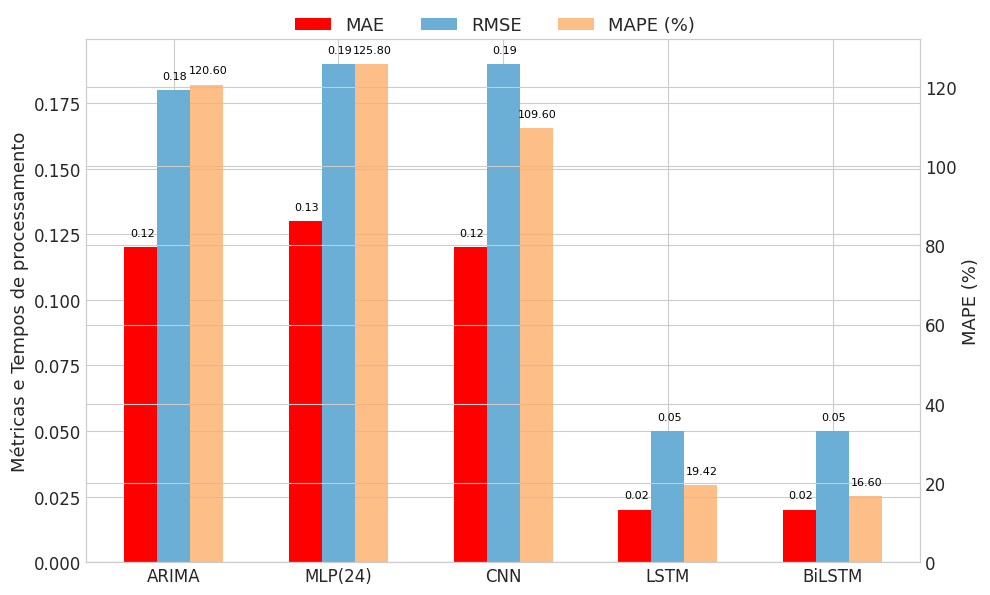

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Dados dos modelos
modelos = ['ARIMA', 'MLP(24)', 'CNN', 'LSTM', 'BiLSTM']
mae =   [0.12, 0.13, 0.12, 0.02, 0.02]
mape =  [120.6, 125.8, 109.6, 19.42, 16.6]
rmse =  [0.18, 0.19, 0.19, 0.05, 0.05]

x = np.arange(len(modelos))
largura = 0.20

fig, ax1 = plt.subplots(figsize=(10, 6))

bar_mae = ax1.bar(x - largura, mae, largura, label='MAE', color='red')
bar_rmse = ax1.bar(x, rmse, largura, label='RMSE', color='#6baed6')
ax1.set_ylabel('Métricas e Tempos de processamento', fontsize=13)
ax1.set_xticks(x)
ax1.set_xticklabels(modelos, fontsize=12)
ax1.tick_params(axis='y', labelsize=12)

ax2 = ax1.twinx()
bar_mape = ax2.bar(x + largura, mape, largura, label='MAPE (%)', color='#fdae6b', alpha=0.8)
ax2.set_ylabel('MAPE (%)', fontsize=13)
ax2.tick_params(axis='y', labelsize=12)

# Legenda afastada para cima
labels = ['MAE', 'RMSE', 'MAPE (%)']
fig.legend([bar_mae, bar_rmse, bar_mape], labels, loc='upper center', ncol=3, fontsize=13, frameon=False, bbox_to_anchor=(0.5, 1.00))

# Adiciona valores "dentro" das barras
def autolabel(bars, ax, fmt='{:.2f}', y_offset=0.003):
    """Adiciona valores nas barras."""
    for bar in bars:
        for rect in bar:
            height = rect.get_height()
            ax.annotate(fmt.format(height),
                        xy=(rect.get_x() + rect.get_width() / 2, height + y_offset),
                        xytext=(1, 1),  # Pequeno deslocamento vertical
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=8, color='black')

autolabel([bar_mae], ax1, fmt='{:.2f}')
autolabel([bar_rmse], ax1, fmt='{:.2f}')
autolabel([bar_mape], ax2, fmt='{:.2f}', y_offset=2.0)

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Deixa espaço para a legenda acima
plt.show()

In [ ]:
def plot_individual_metric_bars(test_metrics, exclude_models=['Baseline']):
    """
    Cria um gráfico de barras individual para cada métrica em figuras separadas.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    # Filtrar modelos excluídos
    test_metrics_filtered = {k: v for k, v in test_metrics.items() if k not in exclude_models}

    # Identificar todas as métricas disponíveis
    all_metrics = set()
    for model_metrics in test_metrics_filtered.values():
        all_metrics.update(model_metrics.keys())

    # Remover 'loss' se outras métricas estiverem disponíveis
    if len(all_metrics) > 1 and 'loss' in all_metrics:
        all_metrics.remove('loss')

    all_metrics = sorted(list(all_metrics))

    # Preparar dados
    models = list(test_metrics_filtered.keys())

    # Cores para os modelos
    colors = plt.cm.viridis(np.linspace(0, 1, len(models)))

    # Mapear nomes de métricas
    metric_titles = {
        'mean_absolute_error': 'Mean Absolute Error (MAE)',
        'mean_squared_error': 'Mean Squared Error (MSE)',
        'root_mean_squared_error': 'Root Mean Squared Error (RMSE)',
        'mean_absolute_percentage_error': 'Mean Absolute Percentage Error (MAPE)',
        'loss': 'Loss',
    }

    # Criar uma figura para cada métrica
    for metric in all_metrics:
        # Coletar valores
        values = []
        valid_models = []

        for model in models:
            if metric in test_metrics_filtered[model]:
                value = test_metrics_filtered[model][metric]

                # Para RMSE, calcular se não estiver disponível
                if metric == 'root_mean_squared_error' and value == 0:
                    if 'mean_squared_error' in test_metrics_filtered[model]:
                        value = np.sqrt(test_metrics_filtered[model]['mean_squared_error'])
                    elif 'loss' in test_metrics_filtered[model]:
                        value = np.sqrt(test_metrics_filtered[model]['loss'])

                values.append(value)
                valid_models.append(model)

        if not values:
            continue

        # Ordenar por valor (melhor para pior)
        sorted_indices = np.argsort(values)
        values = [values[i] for i in sorted_indices]
        valid_models = [valid_models[i] for i in sorted_indices]

        # Criar figura
        fig, ax = plt.subplots(figsize=(12, 8))

        # Cores baseadas no desempenho
        bar_colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(values)))

        # Criar barras
        x_pos = np.arange(len(valid_models))
        bars = ax.bar(x_pos, values, color=bar_colors, alpha=0.8, edgecolor='black', linewidth=1.5)

        # Destacar melhor e pior
        bars[0].set_edgecolor('green')
        bars[0].set_linewidth(3)
        bars[-1].set_edgecolor('red')
        bars[-1].set_linewidth(3)

        # Adicionar valores
        for bar, value in zip(bars, values):
            height = bar.get_height()

            # Formatar valor
            if 'percentage' in metric:
                label = f'{height:.1f}%'
            elif height < 0.01:
                label = f'{height:.2e}'
            elif height < 1:
                label = f'{height:.4f}'
            else:
                label = f'{height:.2f}'

            # Posicionar texto
            y_pos = height + max(values) * 0.01
            ax.text(bar.get_x() + bar.get_width()/2., y_pos,
                   label, ha='center', va='bottom', fontsize=10, fontweight='bold')

        # Configurar gráfico
        ax.set_xlabel('Modelos', fontsize=12, fontweight='bold')
        ax.set_ylabel('Valor', fontsize=12, fontweight='bold')
        ax.set_title(metric_titles.get(metric, metric), fontsize=16, fontweight='bold', pad=15)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(valid_models, rotation=45, ha='right', fontsize=11)
        ax.grid(True, alpha=0.3, axis='y')

        # Adicionar linha de média
        mean_value = np.mean(values)
        ax.axhline(y=mean_value, color='blue', linestyle='--', alpha=0.7,
                  label=f'Média: {mean_value:.4f}')

        # Para MAPE, adicionar referências
        if 'percentage' in metric:
            ax.axhline(y=20, color='green', linestyle='--', alpha=0.5,
                      label='Bom (< 20%)')
            ax.axhline(y=50, color='orange', linestyle='--', alpha=0.5,
                      label='Médio (< 50%)')

        ax.legend(loc='upper left')

        # Adicionar estatísticas
        stats_text = f'Melhor: {valid_models[0]} ({values[0]:.4f})\n'
        stats_text += f'Pior: {valid_models[-1]} ({values[-1]:.4f})\n'
        stats_text += f'Média: {mean_value:.4f}\n'
        stats_text += f'Desvio Padrão: {np.std(values):.4f}'

        ax.text(0.98, 0.97, stats_text, transform=ax.transAxes,
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
               verticalalignment='top', horizontalalignment='right',
               fontsize=10)

        plt.tight_layout()
        plt.show()

In [ ]:
performance = {'Baseline': {'loss': 0.0319359116256237,
  'mean_absolute_error': 0.10684747248888016},
 'Linear': {'loss': 0.030369780957698822,
  'mean_absolute_error': 0.11269021779298782,
  'mean_absolute_percentage_error': 72.14606475830078,
  'mean_squared_error': 0.030369780957698822,
  'root_mean_squared_error': 0.17426927387714386},
 'Dense': {'loss': 0.056839294731616974,
  'mean_absolute_error': 0.15181005001068115,
  'mean_absolute_percentage_error': 85.12030792236328,
  'mean_squared_error': 0.05133695527911186,
  'root_mean_squared_error': 0.22657659649848938},
 'Multi Step dense': {'loss': 0.03441400080919266,
  'mean_absolute_error': 0.12880642712116241,
  'mean_absolute_percentage_error': 78.91421508789062,
  'mean_squared_error': 0.03441400080919266,
  'root_mean_squared_error': 0.18551011383533478},
 'Multi-Step-Dense-24input': {'loss': 0.05076349526643753,
  'mean_absolute_error': 0.16157396137714386,
  'mean_absolute_percentage_error': 94.29467010498047,
  'mean_squared_error': 0.05076349526643753,
  'root_mean_squared_error': 0.22530755400657654},
 'CNN-3Inp-12Out': {'loss': 0.035315729677677155,
  'mean_absolute_error': 0.12863025069236755,
  'mean_absolute_percentage_error': 78.68060302734375,
  'mean_squared_error': 0.035315729677677155,
  'root_mean_squared_error': 0.18792478740215302},
 'LSTM-48Inp-12Out': {'loss': 0.003072916530072689,
  'mean_absolute_error': 0.024819891899824142,
  'mean_absolute_percentage_error': 14.755528450012207,
  'mean_squared_error': 0.003072916530072689,
  'root_mean_squared_error': 0.05543389171361923},
 'BiLSTM-48Inp-12Out': {'loss': 0.002840641653165221,
  'mean_absolute_error': 0.021843254566192627,
  'mean_absolute_percentage_error': 13.282098770141602,
  'mean_squared_error': 0.002840641653165221,
  'root_mean_squared_error': 0.05329766869544983}}

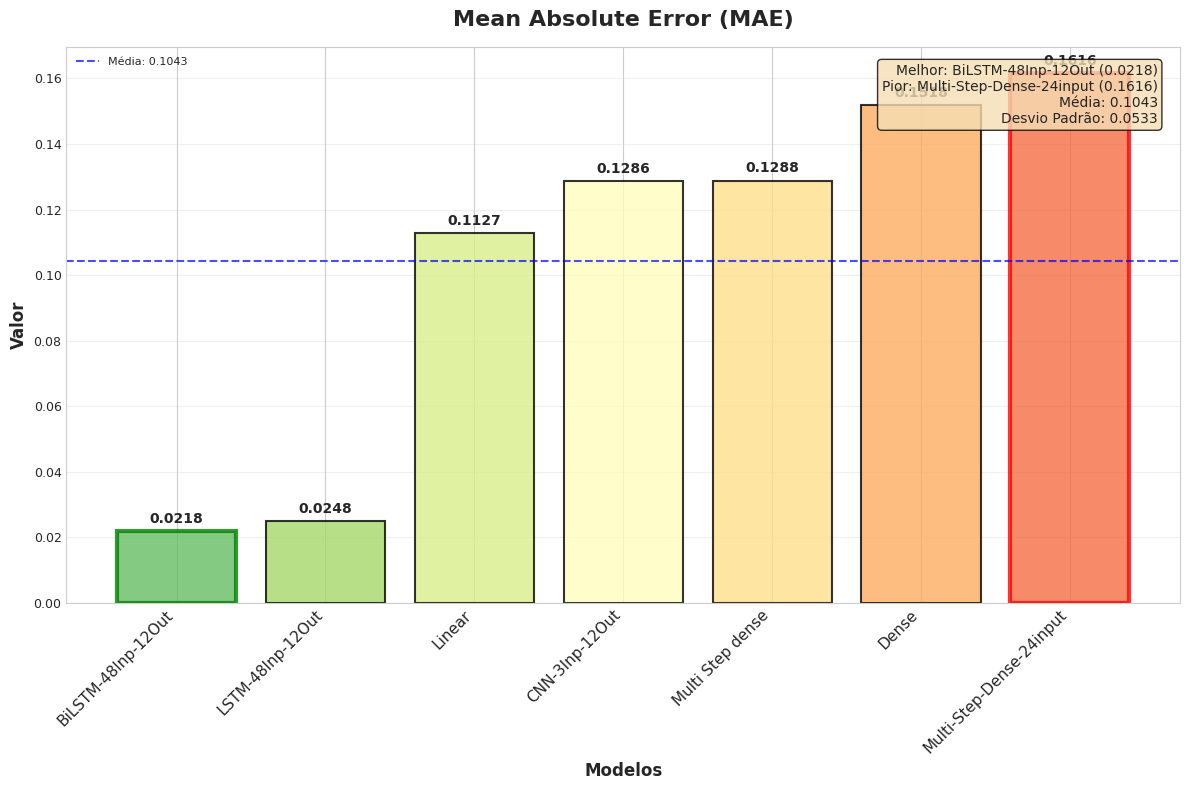

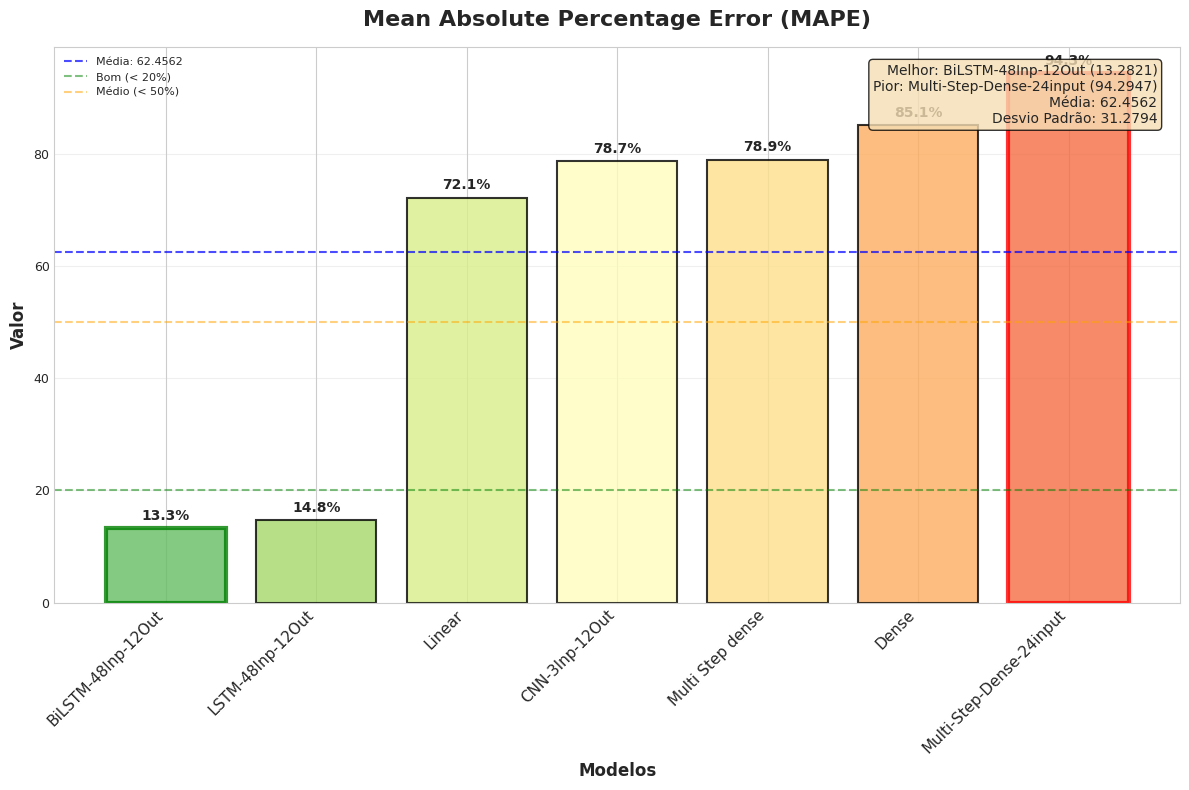

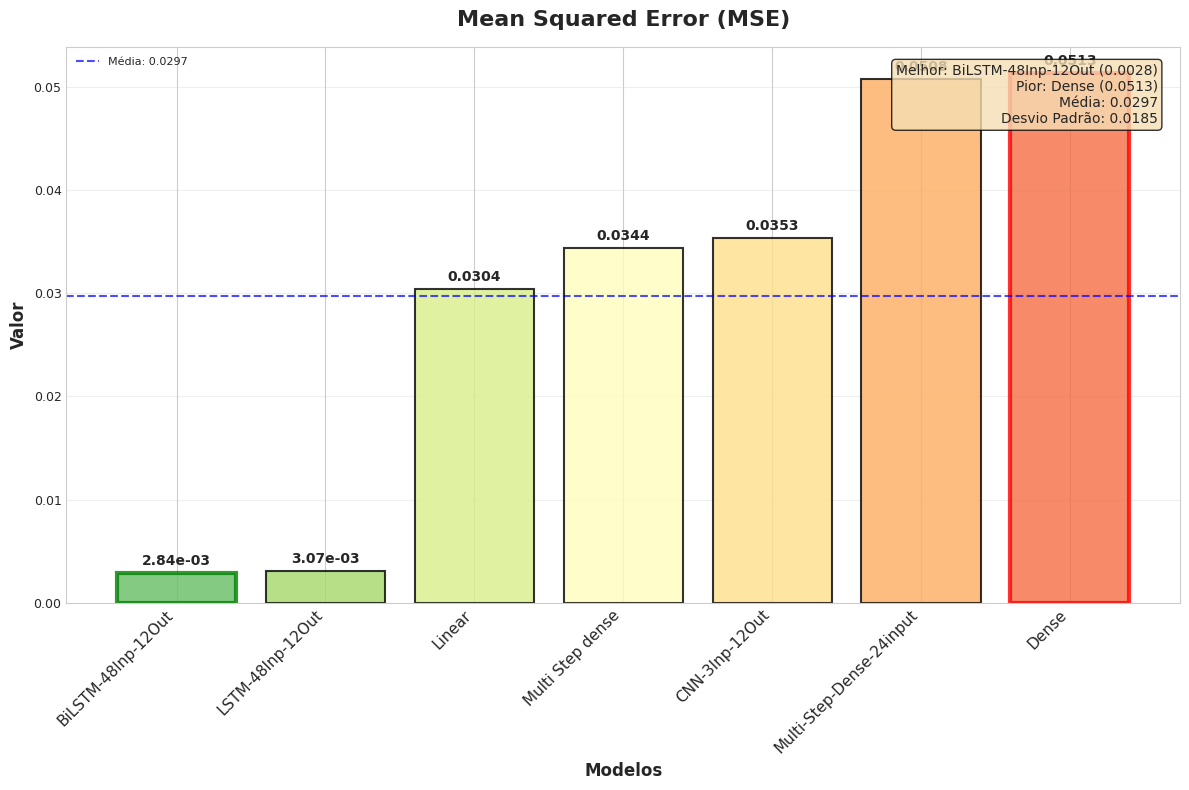

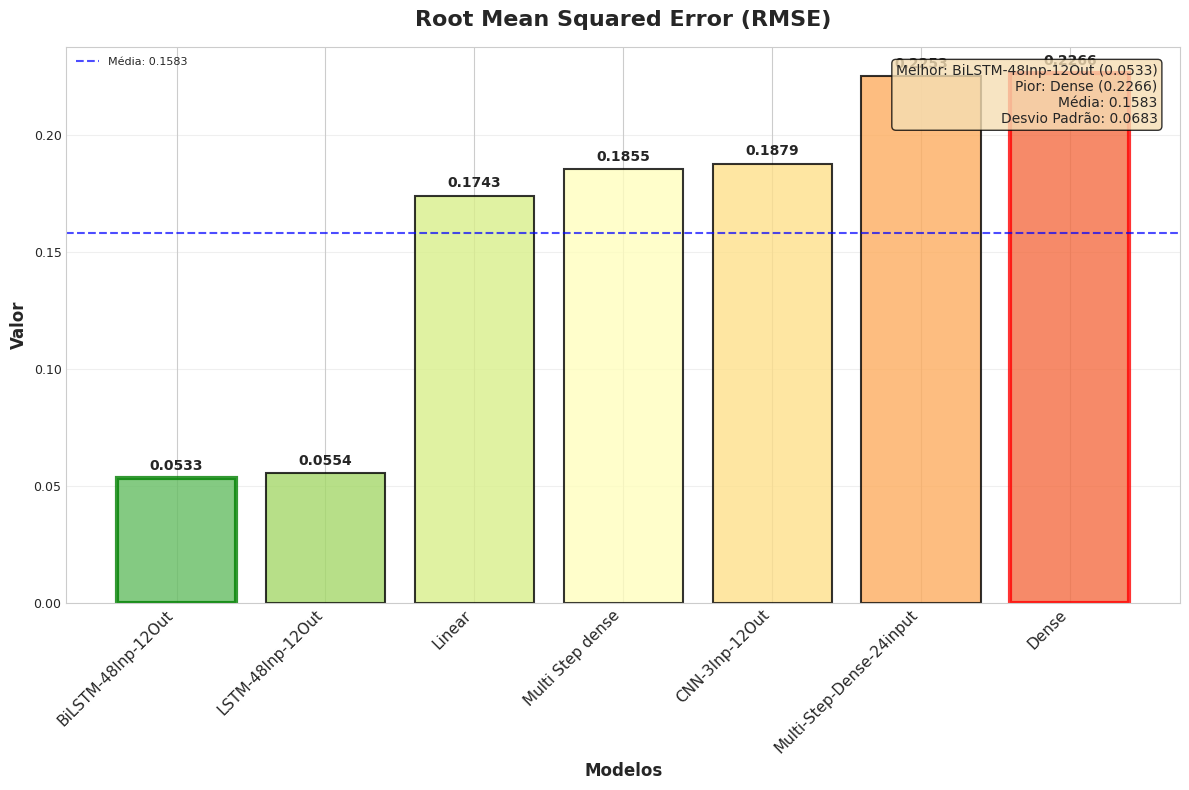

In [ ]:
# 2. Gráficos individuais para cada métrica (um por figura)
plot_individual_metric_bars(performance)

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Dados dos modelos
# modelos = ['ARIMA', 'MLP(24)', 'CNN', 'LSTM', 'BiLSTM']
# mae =   [0.12, 0.13, 0.12, 0.02, 0.02]
# mse = []
# mape =  [120.6, 125.8, 109.6, 19.42, 16.6]
# rmse =  [0.18, 0.19, 0.19, 0.05, 0.05]

# x = np.arange(len(modelos))
# largura = 0.20

# fig, ax1 = plt.subplots(figsize=(10, 6))

# bar_mae = ax1.bar(x - largura, mae, largura, label='MAE', color='red')
# bar_rmse = ax1.bar(x, rmse, largura, label='RMSE', color='#6baed6')
# ax1.set_ylabel('Erro Absoluto / Raiz Quadrada', fontsize=13)
# ax1.set_xticks(x)
# ax1.set_xticklabels(modelos, fontsize=12)
# ax1.tick_params(axis='y', labelsize=12)

# ax2 = ax1.twinx()
# bar_mape = ax2.bar(x + largura, mape, largura, label='MAPE (%)', color='#fdae6b', alpha=0.8)
# ax2.set_ylabel('MAPE (%)', fontsize=13)
# ax2.tick_params(axis='y', labelsize=12)

# # Legenda afastada para cima
# labels = ['MAE', 'RMSE', 'MAPE (%)']
# fig.legend([bar_mae, bar_rmse, bar_mape], labels, loc='upper center', ncol=3, fontsize=13, frameon=False, bbox_to_anchor=(0.5, 1.00))

# # Adiciona valores "dentro" das barras
# def autolabel(bars, ax, fmt='{:.2f}', y_offset=0.003):
#     """Adiciona valores nas barras."""
#     for bar in bars:
#         for rect in bar:
#             height = rect.get_height()
#             ax.annotate(fmt.format(height),
#                         xy=(rect.get_x() + rect.get_width() / 2, height + y_offset),
#                         xytext=(1, 1),  # Pequeno deslocamento vertical
#                         textcoords="offset points",
#                         ha='center', va='bottom', fontsize=8, color='black')

# autolabel([bar_mae], ax1, fmt='{:.2f}')
# autolabel([bar_rmse], ax1, fmt='{:.2f}')
# autolabel([bar_mape], ax2, fmt='{:.2f}', y_offset=2.0)

# plt.tight_layout(rect=[0, 0, 1, 0.96])  # Deixa espaço para a legenda acima
# plt.show()

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Extração dos dados do dicionário
# modelos = list(performance.keys())
# mae = [performance[modelo].get('mean_absolute_error', 0) for modelo in modelos]
# rmse = [performance[modelo].get('root_mean_squared_error', 0) for modelo in modelos]
# mape = [performance[modelo].get('mean_absolute_percentage_error', 0) for modelo in modelos]

# x = np.arange(len(modelos))
# largura = 0.20

# fig, ax1 = plt.subplots(figsize=(12, 7))

# bar_mae = ax1.bar(x - largura, mae, largura, label='MAE', color='red')
# bar_rmse = ax1.bar(x, rmse, largura, label='RMSE', color='#6baed6')
# ax1.set_ylabel('Erro Absoluto / Raiz Quadrada', fontsize=13)
# ax1.set_xlabel('Modelos', fontsize=13)
# ax1.set_xticks(x)
# ax1.set_xticklabels(modelos, rotation=45, ha='right', fontsize=10)
# ax1.tick_params(axis='y', labelsize=12)

# ax2 = ax1.twinx()
# bar_mape = ax2.bar(x + largura, mape, largura, label='MAPE (%)', color='#fdae6b', alpha=0.8)
# ax2.set_ylabel('MAPE (%)', fontsize=13)
# ax2.tick_params(axis='y', labelsize=12)

# # Legenda afastada para cima
# labels = ['MAE', 'RMSE', 'MAPE (%)']
# fig.legend([bar_mae, bar_rmse, bar_mape], labels, loc='upper center', ncol=3, fontsize=13, frameon=False, bbox_to_anchor=(0.5, 1.00))

# # Função para adicionar labels nas barras
# def autolabel(bars, ax, fmt='{:.2f}', y_offset=0.003):
#     """Adiciona valores nas barras."""
#     for bar in bars:
#         for rect in bar:
#             height = rect.get_height()
#             ax.annotate(fmt.format(height),
#                         xy=(rect.get_x() + rect.get_width() / 2, height + y_offset),
#                         xytext=(1, 1),  # Pequeno deslocamento vertical
#                         textcoords="offset points",
#                         ha='center', va='bottom', fontsize=8, color='black')

# autolabel([bar_mae], ax1, fmt='{:.2f}')
# autolabel([bar_rmse], ax1, fmt='{:.2f}')
# autolabel([bar_mape], ax2, fmt='{:.2f}', y_offset=2.0)

# plt.tight_layout(rect=[0, 0, 1, 0.96])  # Deixa espaço para a legenda acima
# plt.title('Comparação de Desempenho dos Modelos', fontsize=15)
# plt.show()


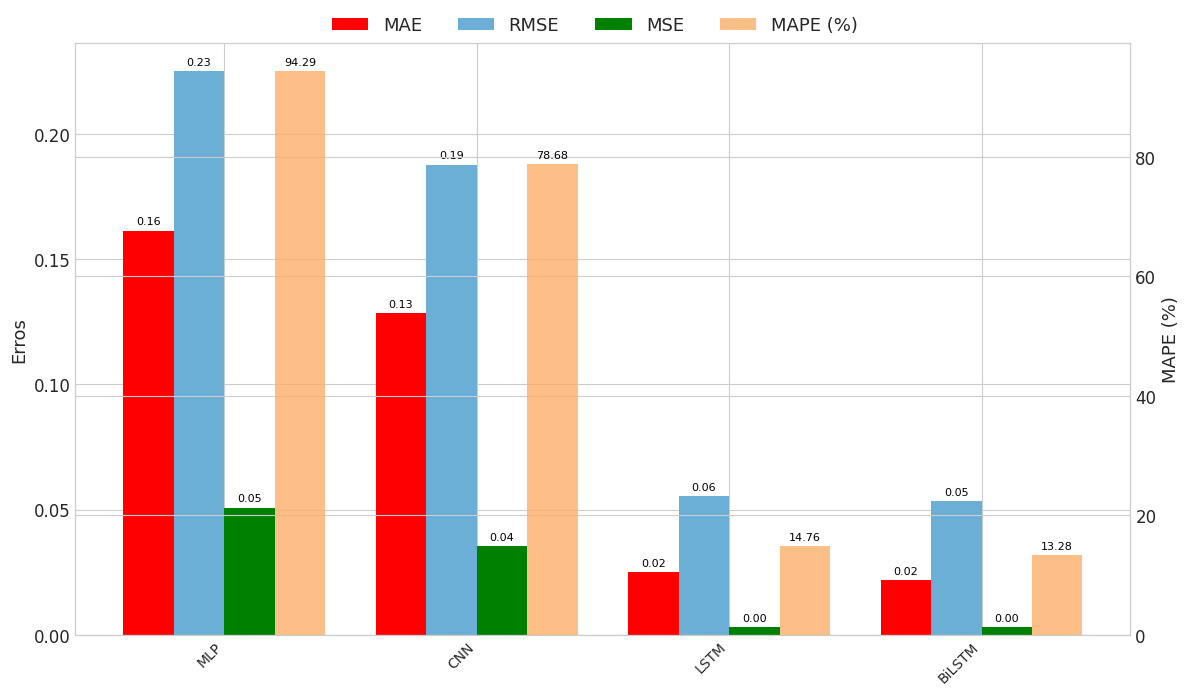

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Dicionário de performance
performance = {
    'MLP': {
        'loss': 0.05076349526643753,
        'mean_absolute_error': 0.16157396137714386,
        'mean_absolute_percentage_error': 94.29467010498047,
        'mean_squared_error': 0.05076349526643753,
        'root_mean_squared_error': 0.22530755400657654
    },
    'CNN': {
        'loss': 0.035315729677677155,
        'mean_absolute_error': 0.12863025069236755,
        'mean_absolute_percentage_error': 78.68060302734375,
        'mean_squared_error': 0.035315729677677155,
        'root_mean_squared_error': 0.18792478740215302
    },
    'LSTM': {
        'loss': 0.003072916530072689,
        'mean_absolute_error': 0.024819891899824142,
        'mean_absolute_percentage_error': 14.755528450012207,
        'mean_squared_error': 0.003072916530072689,
        'root_mean_squared_error': 0.05543389171361923
    },
    'BiLSTM': {
        'loss': 0.002840641653165221,
        'mean_absolute_error': 0.021843254566192627,
        'mean_absolute_percentage_error': 13.282098770141602,
        'mean_squared_error': 0.002840641653165221,
        'root_mean_squared_error': 0.05329766869544983
    }
}

# Extração dos dados do dicionário
modelos = list(performance.keys())
mae   = [performance[modelo].get('mean_absolute_error', 0) for modelo in modelos]
rmse  = [performance[modelo].get('root_mean_squared_error', 0) for modelo in modelos]
mse   = [performance[modelo].get('mean_squared_error', 0) for modelo in modelos]
mape  = [performance[modelo].get('mean_absolute_percentage_error', 0) for modelo in modelos]

x = np.arange(len(modelos))
largura = 0.20

# Definindo os offsets para que as 4 barras fiquem agrupadas de forma centrada
offsets = [-1.5 * largura, -0.5 * largura, 0.5 * largura, 1.5 * largura]

fig, ax1 = plt.subplots(figsize=(12, 7))

# Barras no eixo primário (ax1): MAE, RMSE e MSE
bar_mae   = ax1.bar(x + offsets[0], mae, largura, label='MAE', color='red')
bar_rmse  = ax1.bar(x + offsets[1], rmse, largura, label='RMSE', color='#6baed6')
bar_mse   = ax1.bar(x + offsets[2], mse, largura, label='MSE', color='green')
ax1.set_ylabel('Erros', fontsize=13)
#ax1.set_xlabel('Modelos', fontsize=13)
ax1.set_xticks(x)
ax1.set_xticklabels(modelos, rotation=45, ha='right', fontsize=10)
ax1.tick_params(axis='y', labelsize=12)

# Barra no eixo secundário (ax2): MAPE (%)
ax2 = ax1.twinx()
bar_mape = ax2.bar(x + offsets[3], mape, largura, label='MAPE (%)', color='#fdae6b', alpha=0.8)
ax2.set_ylabel('MAPE (%)', fontsize=13)
ax2.tick_params(axis='y', labelsize=12)

# Legenda combinada para todas as métricas
bars = [bar_mae, bar_rmse, bar_mse, bar_mape]
labels = ['MAE', 'RMSE', 'MSE', 'MAPE (%)']
fig.legend(bars, labels, loc='upper center', ncol=4, fontsize=13, frameon=False, bbox_to_anchor=(0.5, 1.00))

# Função para adicionar os valores nas barras
def autolabel(bars, ax, fmt='{:.2f}', y_offset=0.003):
    """Adiciona os valores nas barras."""
    for bar in bars:
        for rect in bar:
            height = rect.get_height()
            ax.annotate(fmt.format(height),
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # Pequeno deslocamento vertical
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=8, color='black')

autolabel([bar_mae], ax1, fmt='{:.2f}')
autolabel([bar_rmse], ax1, fmt='{:.2f}')
autolabel([bar_mse], ax1, fmt='{:.2f}')
autolabel([bar_mape], ax2, fmt='{:.2f}', y_offset=2.0)

#plt.title('Comparação de Desempenho dos Modelos', fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Espaço para a legenda
plt.savefig('grafico-erros.png', dpi=600)
plt.savefig('grafico-erros.svg', format='svg')
plt.savefig('grafico-erros.eps', format='eps')
plt.show()



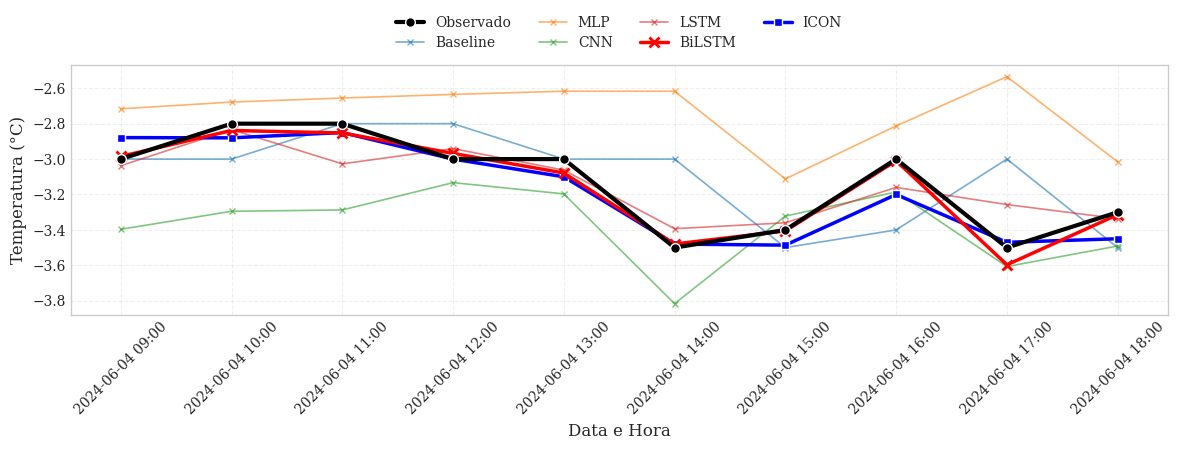

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Criar o DataFrame
data = {
    "Timestamp": [
        "2024-06-04 09:00:00", "2024-06-04 10:00:00", "2024-06-04 11:00:00",
        "2024-06-04 12:00:00", "2024-06-04 13:00:00", "2024-06-04 14:00:00",
        "2024-06-04 15:00:00", "2024-06-04 16:00:00", "2024-06-04 17:00:00",
        "2024-06-04 18:00:00"
    ],
    "Observado": [-3.0, -2.8, -2.8, -3.0, -3.0, -3.5, -3.4, -3.0, -3.5, -3.3],
    "Previsao_Baseline": [-3.0, -3.0, -2.8, -2.8, -3.0, -3.0, -3.5, -3.4, -3.0, -3.5],
    "Previsao_MLP":      [-2.716061, -2.677986, -2.655046, -2.634646, -2.616592,
                          -2.616814, -3.111985, -2.812635, -2.534370, -3.015345],
    "Previsao_CNN":       [-3.396596, -3.294719, -3.287364, -3.132985, -3.196579,
                          -3.816538, -3.321875, -3.185467, -3.606978, -3.490814],
    "Previsao_LSTM":     [-3.037311, -2.833322, -3.026851, -2.940681, -3.062214,
                         -3.393177, -3.359861, -3.159951, -3.256799, -3.336347],
    "Previsao_BiLSTM":   [-2.985098, -2.838319, -2.852353, -2.967930, -3.078631,
                        -3.479675, -3.405823, -3.009067, -3.597097, -3.313753],
    "ICON":              [-2.8786, -2.88, -2.85, -3.00, -3.10, -3.48, -3.486, -3.20, -3.47, -3.45]
}
df = pd.DataFrame(data)
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

# Plot elegante
fig, ax = plt.subplots(figsize=(12, 5))

# Observado
ax.plot(df["Timestamp"], df["Observado"], label="Observado",
        color='black', linewidth=3, marker='o', markersize=7, markeredgecolor='white',
        zorder=5)

# Demais modelos (cores padrão mais suaves)
colors = plt.cm.tab10.colors
for i, col in enumerate(df.columns[2:]):
    if col == "Previsao_BiLSTM":
        ax.plot(df["Timestamp"], df[col], label="BiLSTM",
                color='red', linewidth=2.5, marker='x', markersize=7,
                markeredgewidth=2, zorder=4)
    elif col == "ICON":
        ax.plot(df["Timestamp"], df[col], label="ICON",
                color='blue', linewidth=2.5, marker='s', markersize=6,
                markeredgecolor='white', zorder=3)
    else:
        ax.plot(df["Timestamp"], df[col], label=col.replace("Previsao_", ""),
                color=colors[i % len(colors)], linewidth=1.2, alpha=0.6,
                marker='x', markersize=4, zorder=2)

# Eixo X formatado
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
plt.xticks(rotation=45)
ax.set_xlabel("Data e Hora")
ax.set_ylabel("Temperatura (°C)")

# Grade
ax.grid(True, linestyle='--', alpha=0.3)

# Legenda
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.25),
          ncol=4, frameon=False)

plt.tight_layout()
plt.show()

